In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [214]:
def generate_multivariate_sine(T, d):
    t = np.linspace(0, 1, T)
    
    base_freq = np.random.uniform(2, 3)
    base_phase = np.random.uniform(0, 2*np.pi)
    
    freq_drift = base_freq + 0.2 * np.sin(2*np.pi*t)
    base_signal = np.sin(2 * np.pi * freq_drift * t + base_phase)
    
    X = np.zeros((T, d))
    
    for j in range(d):
        scale = np.random.uniform(0.8, 1.2)
        noise = np.random.normal(0, 0.1, T)
        X[:, j] = scale * base_signal + noise
    
    return X

def generate_multivariate_trend(T, d):
    t = np.linspace(0,1,T)

    base_a = np.random.uniform(0.05,0.5)
    base_b = np.random.uniform(-0.5,0.5)

    base_signal = base_a * t + base_b

    for _ in range(np.random.randint(3, 5)):
        start = np.random.randint(0, T-50)
        length = np.random.randint(100, 500)
        base_signal[start:start+length] -= np.random.uniform(0.1, 0.2)
    
    
    X = np.zeros((T, d))

    for j in range(d):
        scale = np.random.uniform(0.8, 1.2)
        noise = np.random.normal(0, 0.01, T)
        X[:, j] = scale * base_signal + noise

    return X

def generate_multivariate_ar(T,d):
    Y = np.zeros((T,d))
    

    for j in range(d):
        x = np.zeros(T)
        base_phi = np.random.uniform(0.8, 0.98)
        base_noise = np.convolve(
    np.random.normal(0, 0.3, T),
    np.ones(20) / 20,
    mode="same"
)
        for t in range(1, T):
            x[t] = base_phi * x[t - 1] + base_noise[t]
        Y[:, j] = x  
    
    return Y


def generate_timeseries(T=200000, d=15):
    segment_length = T // 8

    X1 = generate_multivariate_trend(segment_length, d)
    X2 = generate_multivariate_sine(segment_length, d)
    X3 = generate_multivariate_ar(segment_length, d)
    X4 = generate_multivariate_trend(segment_length, d)
    X5 = generate_multivariate_sine(segment_length, d)
    X6 = generate_multivariate_ar(segment_length, d)
    X7 = generate_multivariate_sine(segment_length, d)
    X8 = generate_multivariate_trend(segment_length, d)

    # align segments
    def align(prev, curr):
        shift = prev[-1] - curr[0]
        return curr + shift

    X2 = align(X1, X2)
    X3 = align(X2, X3)
    X4 = align(X3, X4)
    X5 = align(X4, X5)
    X6 = align(X5, X6)
    X7 = align(X6, X7)
    X8 = align(X7, X8)

    X = np.vstack([X1, X2, X3, X4, X5, X6, X7, X8])

    y = np.zeros(T)
    return X, y

In [209]:
def plot_mts(X, y): #, regimes):
    T, d = X.shape
    t = np.arange(T)
    
    fig, axes = plt.subplots(5, 1, figsize=(20, 10), sharex=True)
    
    if d == 1:
        axes = [axes]
    
    for j in range(5):
        axes[j].plot(t, X[:, j])
        
        # Highlight anomalies
        anomaly_idx = np.where(y == 1)[0]
        axes[j].scatter(anomaly_idx, X[anomaly_idx, j], s=10)
        
        axes[j].set_ylabel(f"Channel {j}")
    
    
    axes[-1].set_xlabel("Time")
    plt.tight_layout()
    plt.show()

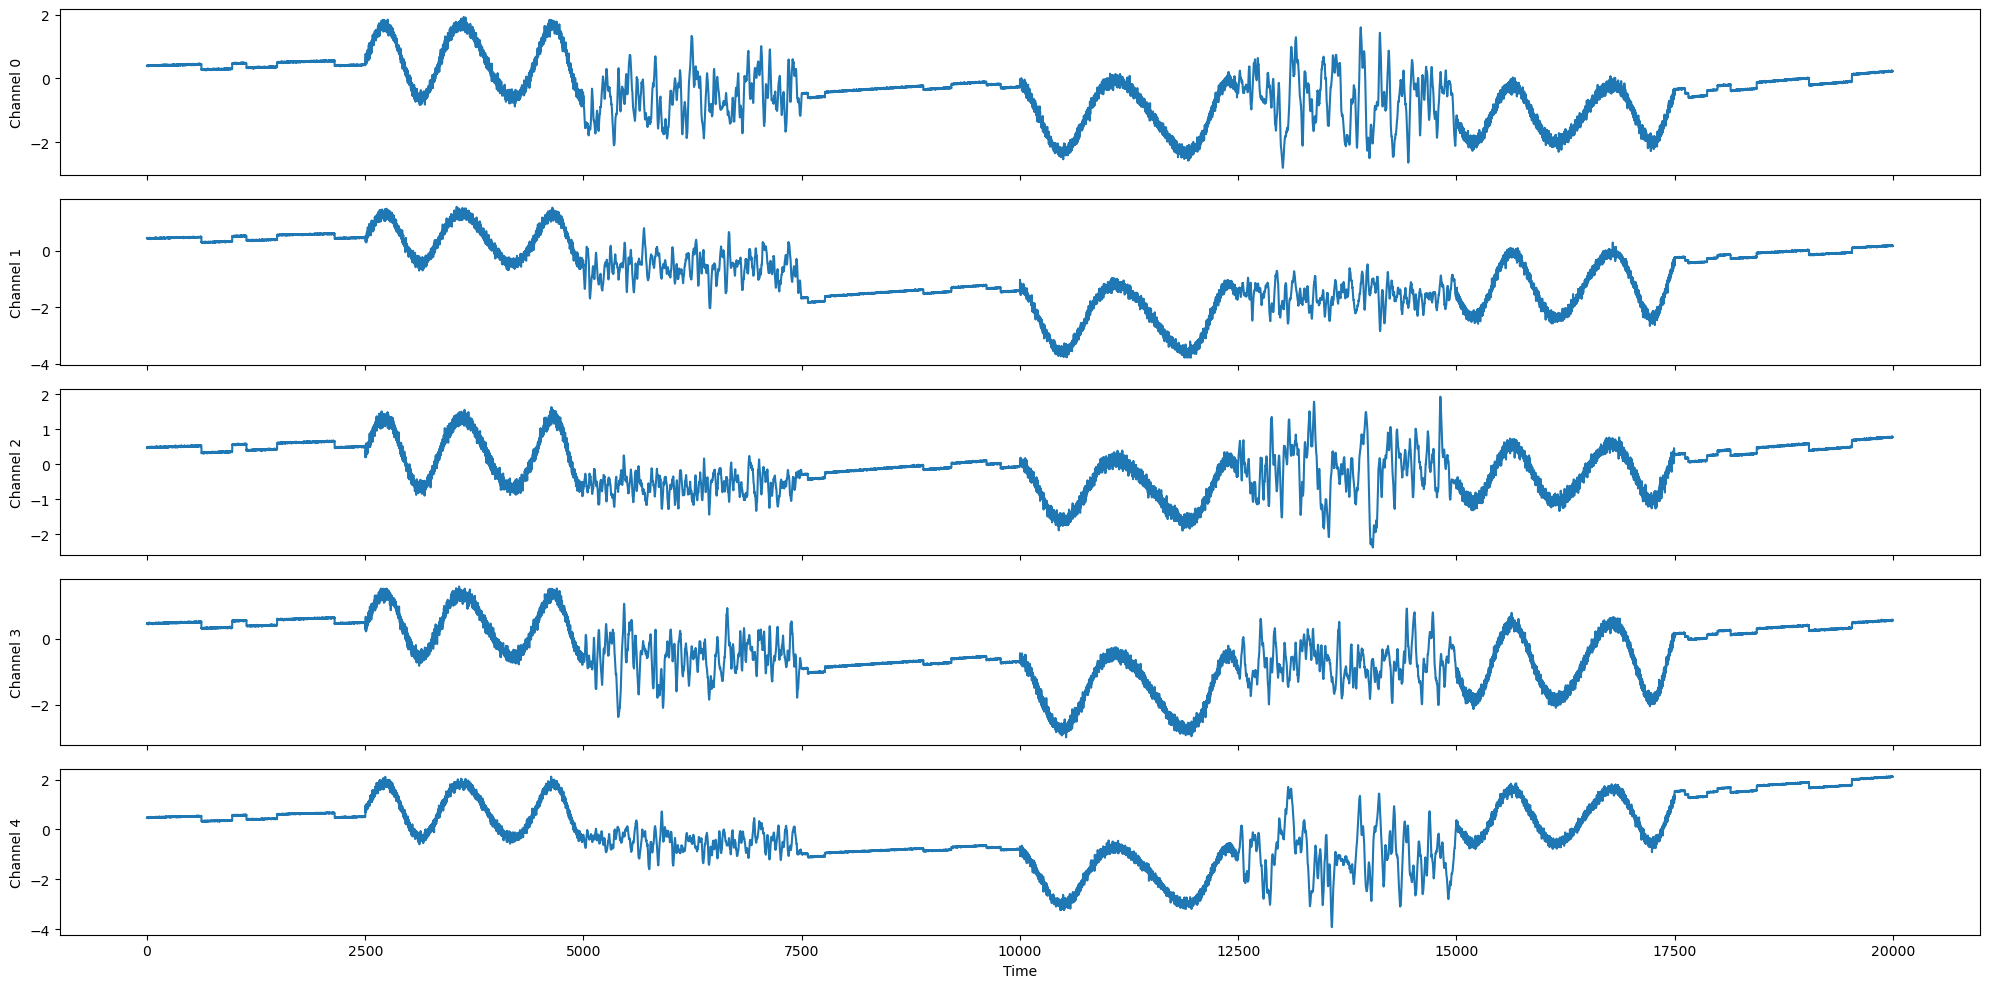

In [215]:
X,y = generate_timeseries(20000, 5)
plot_mts(X,y)